<a href="https://colab.research.google.com/github/lkumare447-byte/EE_machine_learning/blob/main/task_10_EE_509.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np

In [3]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self,output_gradient, learning_rate):
        pass

In [27]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, learning_rate):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        return input_gradient

In [5]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

In [6]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [7]:
class Tanh(Activation):
    def __init__(self):
        def tanh(x):
            return np.tanh(x)

        def tanh_prime(x):
            return 1- np.tanh(x) ** 2

        super().__init__(tanh, tanh_prime)

In [9]:
class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))

        def sigmoid_prime(x):
            s = sigmoid(x)
            return s * (1-s)

        super().__init__(sigmoid, sigmoid_prime)

In [10]:
import math

In [11]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x

        def linear_prime(x):
            return 1

        super().__init__(linear, linear_prime)

In [12]:
X = np.linspace(-3,3,61)
Y = [math.sin(p) for p in X]

network = [
    Dense(1, 10),
    Tanh(),
    Dense(10, 1),
    Linear()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(X,Y):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(X)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=10.300156192004033
2/(50, error=1.9901378189018037
3/(50, error=0.31786388974000396
4/(50, error=0.34517168480006993
5/(50, error=0.050289147343373544
6/(50, error=0.0545253363964644
7/(50, error=0.04112270840699392
8/(50, error=0.03262802467826948
9/(50, error=0.022670367429550028
10/(50, error=0.015015915759373478
11/(50, error=0.00921967409506781
12/(50, error=0.0068386105379897415
13/(50, error=0.0049597593436120566
14/(50, error=0.0025837996462076997
15/(50, error=0.001674623187186201
16/(50, error=0.0015142469973224693
17/(50, error=0.0016435174776238052
18/(50, error=0.002346150506232011
19/(50, error=0.004160779061272594
20/(50, error=0.00693169365916249
21/(50, error=0.010371394091722426
22/(50, error=0.014009988802113951
23/(50, error=0.017297203539210052
24/(50, error=0.019884660553222726
25/(50, error=0.02168000923540229
26/(50, error=0.022746356553382065
27/(50, error=0.02320888115665393
28/(50, error=0.023209780415087318
29/(50, error=0.022885684167658352
30/

In [13]:
actual_Y = []
for x in X:
    output = x
    for layer in network:
        output = layer.forward(output)
    actual_Y.append(output[0])
print(output)

[[0.38355403]]


In [14]:
import matplotlib.pyplot as plt


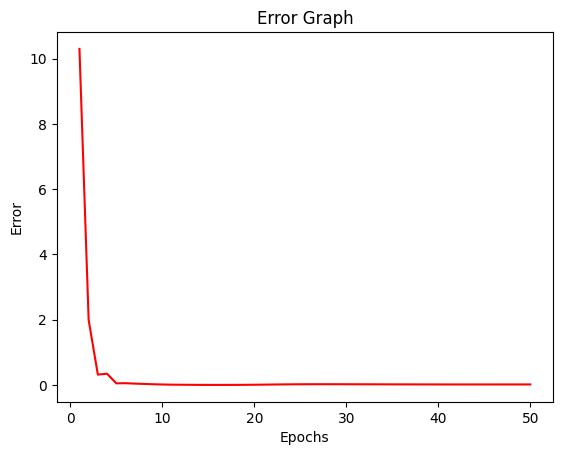

In [16]:
plt.plot(range(1, epochs + 1), errorlist, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [18]:
def preprocess_data(x, y, limit):
        x = x.reshape(x.shape[0], 28 * 28, 1)
        x = x.astype("float32")/255

        y = to_categorical(y)
        y = y.reshape(y.shape[0], 10, 1)

        return x[:limit], y[:limit]


In [33]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, y_train = preprocess_data(x_train, y_train, 1000)
x_test, y_test = preprocess_data(x_test, y_test, 1000)

# Defining the MNIST specific network architecture (784 -> 80 -> 10)
network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x, y in zip(x_train, y_train):
        output = x
        for layer in network:
            output = layer.forward(output)
        error += mse(y, output)
        grad = mse_prime(y, output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(x_train)
    print(f"{e + 1}/{epochs}, error={error}")
    errorlist.append(error)

1/50, error=0.237633199342243
2/50, error=0.17960668968280274
3/50, error=0.17602835566210487
4/50, error=0.17400788209118917
5/50, error=0.17225237854477846
6/50, error=0.170519441676382
7/50, error=0.16884409325295988
8/50, error=0.16726104928590732
9/50, error=0.16569802335305509
10/50, error=0.16412990650626214
11/50, error=0.1626106125523158
12/50, error=0.16118743723419704
13/50, error=0.15985518180726166
14/50, error=0.15856572455674872
15/50, error=0.15728187814007422
16/50, error=0.15603942432113474
17/50, error=0.15487145757500548
18/50, error=0.153767712682962
19/50, error=0.1527027692904039
20/50, error=0.15166332377698682
21/50, error=0.15065415859308662
22/50, error=0.14968711911801136
23/50, error=0.14877210828593576
24/50, error=0.14790706339686738
25/50, error=0.14707607860276262
26/50, error=0.14626134400349114
27/50, error=0.14545646766065476
28/50, error=0.14467416397258998
29/50, error=0.14393457485481284
30/50, error=0.14324743644956234
31/50, error=0.142608150828

In [19]:
def predict(network, input):
    output = input
    for layer in network:
        output = layer.forward(output)
    return output


In [22]:
!pip install simple_colors
import simple_colors

In [34]:
# Automatically load and preprocess the test data if not already defined
if 'x_test' not in globals() or 'y_test' not in globals():
    from keras.datasets import mnist
    (_, _), (x_test, y_test) = mnist.load_data()
    x_test, y_test = preprocess_data(x_test, y_test, 1000)

correct = 0
for x, y in zip(x_test, y_test):
    output = predict(network, x)
    if np.argmax(output) == np.argmax(y):
        correct += 1
        print('pred:', np.argmax(output), '\ttrue:', np.argmax(y))
    else:
        print(simple_colors.red(f'pred: {np.argmax(output)} \ttrue: {np.argmax(y)}'))

accuracy = correct / len(y_test)
print(f"Accuracy: {accuracy}")
print(f"Correct: {correct}")

pred: 6 	true: 7
pred: 6 	true: 2
pred: 6 	true: 1
pred: 6 	true: 0
pred: 6 	true: 4
pred: 6 	true: 1
pred: 6 	true: 4
pred: 6 	true: 9
pred: 6 	true: 5
pred: 6 	true: 9
pred: 6 	true: 0
pred: 6 	true: 6
pred: 6 	true: 9
pred: 6 	true: 0
pred: 6 	true: 1
pred: 6 	true: 5
pred: 6 	true: 9
pred: 6 	true: 7
pred: 6 	true: 3
pred: 6 	true: 4
pred: 6 	true: 9
pred: 6 	true: 6
pred: 6 	true: 6
pred: 6 	true: 5
pred: 6 	true: 4
pred: 6 	true: 0
pred: 6 	true: 7
pred: 6 	true: 4
pred: 6 	true: 0
pred: 6 	true: 1
pred: 6 	true: 3
pred: 6 	true: 1
pred: 6 	true: 3
pred: 6 	true: 4
pred: 6 	true: 7
pred: 6 	true: 2
pred: 6 	true: 7
pred: 6 	true: 1
pred: 6 	true: 2
pred: 6 	true: 1
pred: 6 	true: 1
pred: 6 	true: 7
pred: 6 	true: 4
pred: 6 	true: 2
pred: 6 	true: 3
pred: 6 	true: 5
pred: 6 	true: 1
pred: 6 	true: 2
pred: 6 	true: 4
pred: 6 	true: 4
pred: 6 	true: 6
pred: 6 	true: 3
pred: 6 	true: 5
pred: 6 	true: 5
pred: 6 	true: 6
pred: 6 	true: 0
pred: 6 	true: 4
pred: 6 	true: 1
pred: 6 	true:

In [30]:
error = errorlist
X = list(range(1, len(errorlist) + 1))

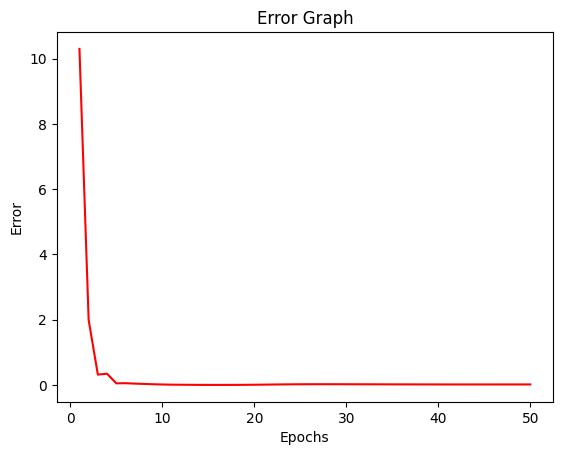

In [31]:
plt.plot(X, error, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()